# **1. Perkenalan Dataset**


1. **Sumber Dataset**:  
   Dataset diperoleh dari berbagai sumbe *Kaggle*

   https://www.kaggle.com/code/mohamedelaziz/fashion-retail


# **2. Import Library**

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

colors = ["#89CFF0", "#FF69B4", "#FFD700", "#7B68EE", "#FF4500",
          "#9370DB", "#32CD32", "#8A2BE2", "#FF6347", "#20B2AA",
          "#FF69B4", "#00CED1", "#FF7F50", "#7FFF00", "#DA70D6"]

# **3. Memuat Dataset**

In [62]:
df = pd.read_csv('Fashion_Retail_Sales.csv')

In [63]:
styled_df = df.style.set_table_styles([
    {'selector': 'th', 'props': [('background', '#36454F'), ('color', 'white')]},
    {'selector': 'td', 'props': [('background', '#282828'), ('color', 'white')]}
])
styled_df

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
0,4018,Handbag,4619.000000,2023-02-05,nan,Credit Card
1,4115,Tunic,2456.000000,2023-07-11,2.000000,Credit Card
2,4019,Tank Top,2102.000000,2023-03-23,4.100000,Cash
3,4097,Leggings,3126.000000,2023-03-15,3.200000,Cash
4,3997,Wallet,3003.000000,2022-11-27,4.700000,Cash
5,4080,Onesie,2914.000000,2022-12-11,4.500000,Credit Card
6,4055,Jacket,2571.000000,2023-07-08,1.300000,Cash
7,3973,Trousers,2419.000000,2022-11-10,4.600000,Cash
8,4044,Jeans,4771.000000,2023-05-19,4.100000,Cash
9,4010,Loafers,4233.000000,2023-06-11,nan,Credit Card


Tabel Data Sample

In [64]:
df.sample(7)


,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
485,3986,Jumpsuit,136.0,2022-12-14,NaN,Cash
1438,4092,Sandals,148.0,2022-12-06,1.6,Cash
953,4052,Handbag,27.0,2023-09-11,1.7,Cash
113,3991,Boots,27.0,2023-09-16,2.0,Credit Card
1870,4116,Hoodie,124.0,2023-08-20,2.0,Credit Card
1041,3961,Handbag,NaN,2023-08-28,3.7,Cash
2173,4086,Belt,145.0,2022-10-29,3.5,Cash


# **4. Exploratory Data Analysis (EDA)**



In [65]:
# Cek informasi tipe data dan nilai kosong
df.info()

# Cek jumlah nilai yang hilang (missing values)
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 2   Purchase Amount (USD)  2750 non-null   float64
 3   Date Purchase          3400 non-null   object 
 4   Review Rating          3076 non-null   float64
 5   Payment Method         3400 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 159.5+ KB

Jumlah Missing Values per Kolom:
Customer Reference ID      0
Item Purchased             0
Purchase Amount (USD)    650
Date Purchase              0
Review Rating            324
Payment Method             0
dtype: int64


**A. Statistik Deskriptif**

In [66]:
df.describe()

,Customer Reference ID,Purchase Amount (USD),Review Rating
count,3400.000000,2750.000000,3076.000000
mean,4039.660588,156.709818,2.999057
std,48.122583,419.536669,1.156505
min,3957.000000,10.000000,1.000000
25%,3997.000000,57.000000,2.000000
50%,4040.000000,110.000000,3.000000
75%,4081.000000,155.750000,4.000000
max,4122.000000,4932.000000,5.000000


**B. Visualisasi Data**

Hasil Distribusi

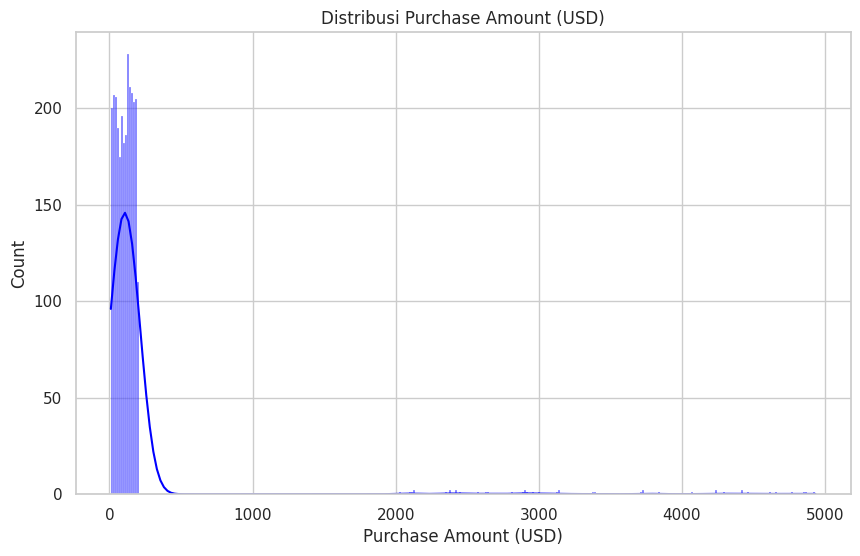

In [67]:
# 1. Distribusi Purchase Amount (USD)
plt.figure(figsize=(10, 6))
sns.histplot(df['Purchase Amount (USD)'].dropna(), kde=True, color='blue')
plt.title('Distribusi Purchase Amount (USD)')
plt.show()

Perbandingan Metode Pembayaran

In [68]:
payment_counts = df["Payment Method"].value_counts(normalize=True) * 100

# Membuat DataFrame statistik dengan label Bahasa Indonesia
payment_stats = pd.DataFrame({
    "Metode Pembayaran": payment_counts.index,
    "Jumlah (Proporsi)": payment_counts.values,
    "Persentase (%)": payment_counts.values.round(2)
})

In [69]:
# Menampilkan tabel dengan gaya (Styling)
styled_table = payment_stats.style.format({"Persentase (%)": "{:.2f}%"}).background_gradient(cmap='Blues')
display(styled_table)

,Metode Pembayaran,Jumlah (Proporsi),Persentase (%)
0,Credit Card,52.058824,52.06%
1,Cash,47.941176,47.94%


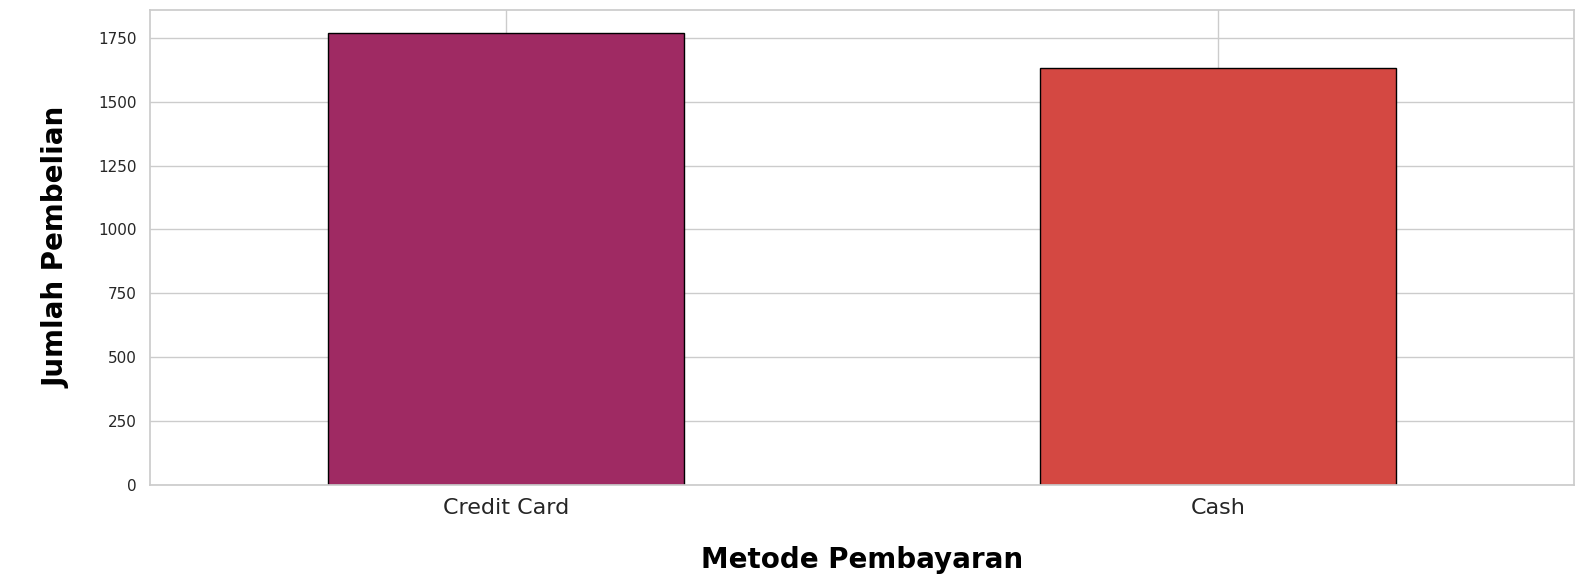

In [70]:
# Membuat Visualisasi (Bar Chart)
plt.figure(figsize = (16, 6))
df["Payment Method"].value_counts().sort_values(ascending = False).plot(
    kind = 'bar',
    color = sns.color_palette('inferno')[2:4],
    edgecolor = 'black'
)

# Mengatur Label Sumbu X dan Y dalam Bahasa Indonesia
plt.xlabel('Metode Pembayaran', weight = "bold", color = "black", fontsize = 20, labelpad = 20)
plt.ylabel('\nJumlah Pembelian', weight = "bold", color = "black", fontsize = 20, labelpad = 20)

plt.xticks(rotation = 0, ha = 'center', fontsize = 16)
plt.tight_layout()
plt.show()

Top 10 item yang sering dibeli

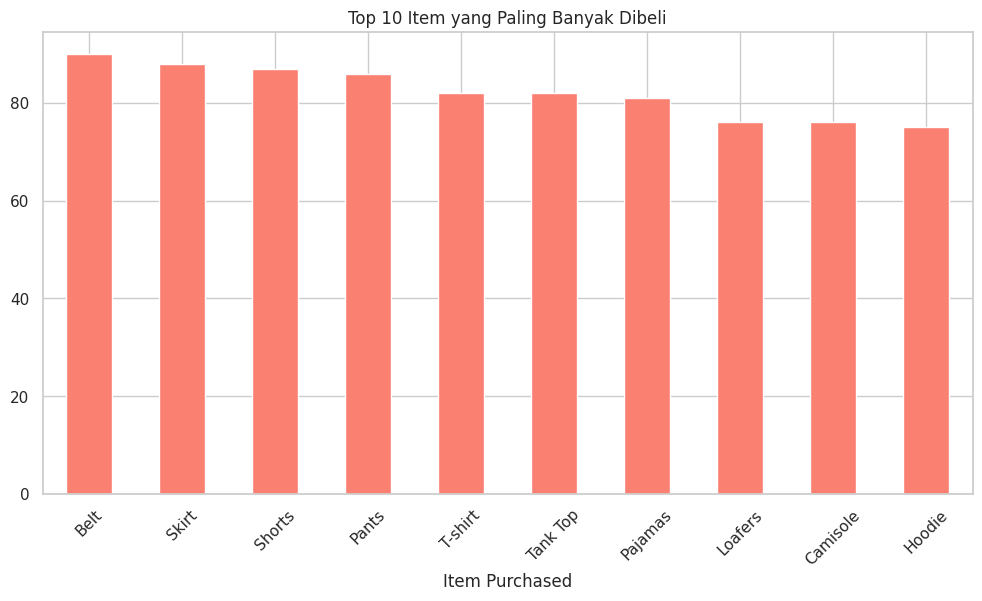

In [71]:
plt.figure(figsize=(12, 6))
df['Item Purchased'].value_counts().head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Item yang Paling Banyak Dibeli')
plt.xticks(rotation=45)
plt.show()

# **5. Data Preprocessing**

In [72]:
# 1. Menangani Missing Values
# Mengisi Purchase Amount yang kosong dengan median
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(df['Purchase Amount (USD)'].median())

# Mengisi Review Rating yang kosong dengan rata-rata (atau nilai default)
df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].mean())

# 2. Konversi Tipe Data
# Mengubah Date Purchase menjadi format datetime
df['Date Purchase'] = pd.to_datetime(df['Date Purchase'])

# 3. Menghapus Data Duplikat (jika ada)
df = df.drop_duplicates()

# 4. Feature Encoding (Opsional untuk Eksperimen)
# Misalnya mengonversi Payment Method menjadi kategori numerik
df['Payment_Method_Code'] = df['Payment Method'].astype('category').cat.codes

# Menampilkan hasil akhir preprocessing
print("Data setelah Preprocessing:")
df.info()
df.head()

Data setelah Preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Customer Reference ID  3400 non-null   int64         
 1   Item Purchased         3400 non-null   object        
 2   Purchase Amount (USD)  3400 non-null   float64       
 3   Date Purchase          3400 non-null   datetime64[ns]
 4   Review Rating          3400 non-null   float64       
 5   Payment Method         3400 non-null   object        
 6   Payment_Method_Code    3400 non-null   int8          
dtypes: datetime64[ns](1), float64(2), int64(1), int8(1), object(2)
memory usage: 162.8+ KB


,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method,Payment_Method_Code
0,4018,Handbag,4619.0,2023-02-05,2.999057,Credit Card,1
1,4115,Tunic,2456.0,2023-07-11,2.000000,Credit Card,1
2,4019,Tank Top,2102.0,2023-03-23,4.100000,Cash,0
3,4097,Leggings,3126.0,2023-03-15,3.200000,Cash,0
4,3997,Wallet,3003.0,2022-11-27,4.700000,Cash,0
